In [1]:
%pip install thundersvm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

In [2]:
train1 = pd.read_csv(r"C:\bt23ece064\wavelet\saved_dfs\train_df_1.csv")
test1 = pd.read_csv(r"C:\bt23ece064\wavelet\saved_dfs\test_df_1.csv")



In [4]:
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from thundersvm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, precision_recall_curve, 
    confusion_matrix
)
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

def tune_svm_with_optuna(X, y, n_trials=30, k_folds=3):
    def objective(trial):
        C = trial.suggest_float('C', 1e-3, 1e3, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_float('gamma', 1e-4, 10.0, log=True) if kernel != 'linear' else 'scale'
        degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3

        clf = SVC(
            C=C,
            kernel=kernel,
            gamma=gamma if kernel != 'linear' else 'scale',
            degree=degree,
            probability=True,
            random_state=42
        )

        skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
        aucs = []
        for train_idx, val_idx in skf.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            clf.fit(X_train, y_train)
            probs = clf.predict_proba(X_val)[:, 1]
            aucs.append(roc_auc_score(y_val, probs))
        return np.mean(aucs)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_clf = SVC(
        C=best_params['C'],
        kernel=best_params['kernel'],
        gamma=best_params['gamma'] if best_params['kernel'] != 'linear' else 'scale',
        degree=best_params['degree'] if best_params['kernel'] == 'poly' else 3,
        probability=True,
        random_state=42
    )
    return best_clf, study




FileNotFoundError: Please build the library first!

In [4]:
from sklearn.metrics import roc_curve

def evaluate_model(clf, X_train, X_test, y_train, y_test, scaler=None):
    if scaler:
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)

    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    probas = clf.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    accuracy = accuracy_score(y_test, preds)
    auroc = roc_auc_score(y_test, probas)
    auprc = average_precision_score(y_test, probas)
    cm = confusion_matrix(y_test, preds)

    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUROC:     {auroc:.4f}")

    # Plot ROC Curve instead of Precision-Recall Curve
    fpr, tpr, _ = roc_curve(y_test, probas)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUROC = {auroc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auroc': auroc,
        'confusion_matrix': cm
    }


In [5]:
def run_pipeline(train_df, test_df):
    # Drop non-feature columns if needed
    X_train = train_df.drop(columns=["label", "wavelet"], errors="ignore").values
    y_train = train_df["label"].values
    X_test = test_df.drop(columns=["label", "wavelet"], errors="ignore").values
    y_test = test_df["label"].values

    # Scale and SMOTE
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

    # Tune SVM
    clf, study = tune_svm_with_optuna(X_train_bal, y_train_bal, n_trials=30)

    # Evaluate
    evaluate_model(clf, X_train_bal, X_test_scaled, y_train_bal, y_test)

    return clf, study


In [4]:
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, roc_curve, confusion_matrix
)
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

def train_evaluate_svm(train_df, test_df, n_trials=30, k_folds=3, result_file="svm_results.txt"):
    # Prepare data
    X_train = train_df.drop(columns=["label", "wavelet"], errors="ignore").values
    y_train = train_df["label"].values
    X_test = test_df.drop(columns=["label", "wavelet"], errors="ignore").values
    y_test = test_df["label"].values

    # Scale data
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply SMOTE to handle imbalance
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

    # Define Optuna objective
    def objective(trial):
        C = trial.suggest_float('C', 1e-3, 1e3, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_float('gamma', 1e-4, 10.0, log=True) if kernel != 'linear' else 'scale'
        degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3

        clf = SVC(
            C=C,
            kernel=kernel,
            gamma=gamma if kernel != 'linear' else 'scale',
            degree=degree,
            probability=True,
            random_state=42
        )

        skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
        aucs = []
        for train_idx, val_idx in skf.split(X_train_bal, y_train_bal):
            X_tr, X_val = X_train_bal[train_idx], X_train_bal[val_idx]
            y_tr, y_val = y_train_bal[train_idx], y_train_bal[val_idx]
            clf.fit(X_tr, y_tr)
            probs = clf.predict_proba(X_val)[:, 1]
            aucs.append(roc_auc_score(y_val, probs))
        return np.mean(aucs)

    # Run Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params
    best_clf = SVC(
        C=best_params['C'],
        kernel=best_params['kernel'],
        gamma=best_params['gamma'] if best_params['kernel'] != 'linear' else 'scale',
        degree=best_params['degree'] if best_params['kernel'] == 'poly' else 3,
        probability=True,
        random_state=42
    )

    # Train best model on full balanced training set
    best_clf.fit(X_train_bal, y_train_bal)

    # Predict and evaluate on test set
    preds = best_clf.predict(X_test_scaled)
    probas = best_clf.predict_proba(X_test_scaled)[:, 1]

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    accuracy = accuracy_score(y_test, preds)
    auroc = roc_auc_score(y_test, probas)
    auprc = average_precision_score(y_test, probas)
    cm = confusion_matrix(y_test, preds)

    # Save results to text file
    with open(result_file, "w") as f:
        f.write("Confusion Matrix:\n")
        f.write(np.array2string(cm))
        f.write("\n\n")
        f.write(f"Accuracy:  {accuracy:.4f}\n")
        f.write(f"Precision: {precision:.4f}\n")
        f.write(f"Recall:    {recall:.4f}\n")
        f.write(f"F1 Score:  {f1:.4f}\n")
        f.write(f"AUROC:     {auroc:.4f}\n")
        f.write(f"AUPRC:     {auprc:.4f}\n\n")

        f.write("Best Hyperparameters found by Optuna:\n")
        for param, val in best_params.items():
            f.write(f"{param}: {val}\n")

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, probas)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUROC = {auroc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return best_clf, study

 

In [ ]:
train_evaluate_svm(train_df=train1, test_df=test1)

[I 2025-07-02 16:06:15,298] A new study created in memory with name: no-name-58832c51-6ca3-489a-a77c-2c22434ebac8
[I 2025-07-02 16:07:40,898] Trial 0 finished with value: 0.5814267813220817 and parameters: {'C': 0.34494274754498355, 'kernel': 'linear'}. Best is trial 0 with value: 0.5814267813220817.
[I 2025-07-02 16:07:41,700] Trial 5 finished with value: 0.5666910496688577 and parameters: {'C': 0.10632130277779248, 'kernel': 'linear'}. Best is trial 0 with value: 0.5814267813220817.
[I 2025-07-02 16:07:43,975] Trial 10 finished with value: 0.5473039051756965 and parameters: {'C': 0.02074382253620519, 'kernel': 'linear'}. Best is trial 0 with value: 0.5814267813220817.
[I 2025-07-02 16:07:44,739] Trial 6 finished with value: 0.8603412043047413 and parameters: {'C': 2.1972183902966482, 'kernel': 'rbf', 'gamma': 9.202574729757085}. Best is trial 6 with value: 0.8603412043047413.
[I 2025-07-02 16:07:45,802] Trial 3 finished with value: 0.5817037112535242 and parameters: {'C': 9.719714600

[I 2025-07-02 12:45:46,563] A new study created in memory with name: no-name-4e5693ae-f4e0-4a1d-807c-8e2ef92c0fee
[I 2025-07-02 12:46:16,822] Trial 0 finished with value: 0.4714955401669944 and parameters: {'C': 0.004333131735025079, 'kernel': 'linear'}. Best is trial 0 with value: 0.4714955401669944.
[I 2025-07-02 12:46:17,229] Trial 7 finished with value: 0.5601642091071106 and parameters: {'C': 9.865233529192844, 'kernel': 'linear'}. Best is trial 7 with value: 0.5601642091071106.
[I 2025-07-02 12:46:18,998] Trial 3 finished with value: 0.5588770830769514 and parameters: {'C': 6.011365004805136, 'kernel': 'linear'}. Best is trial 7 with value: 0.5601642091071106.
[I 2025-07-02 12:46:19,481] Trial 2 finished with value: 0.5541449297188166 and parameters: {'C': 1.8647625725234367, 'kernel': 'linear'}. Best is trial 7 with value: 0.5601642091071106.
[I 2025-07-02 12:46:20,108] Trial 6 finished with value: 0.475628998028307 and parameters: {'C': 644.0107447659876, 'kernel': 'poly', 'gam

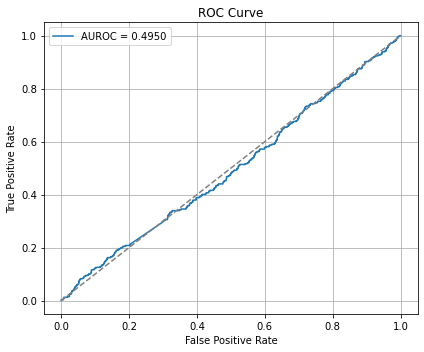

[I 2025-07-02 12:58:32,627] A new study created in memory with name: no-name-dc3fa8bb-4532-4d78-83d0-edc480fa033b
[I 2025-07-02 12:58:59,642] Trial 10 finished with value: 0.5002993563233608 and parameters: {'C': 0.03443194272001763, 'kernel': 'linear'}. Best is trial 10 with value: 0.5002993563233608.
[I 2025-07-02 12:59:01,493] Trial 7 finished with value: 0.47584877700727435 and parameters: {'C': 0.03152284758321136, 'kernel': 'poly', 'gamma': 0.0013879199421468276, 'degree': 5}. Best is trial 10 with value: 0.5002993563233608.
[I 2025-07-02 12:59:02,279] Trial 4 finished with value: 0.5387685636977544 and parameters: {'C': 0.004391819281035504, 'kernel': 'poly', 'gamma': 0.5519901027262561, 'degree': 3}. Best is trial 4 with value: 0.5387685636977544.
[I 2025-07-02 12:59:02,359] Trial 0 finished with value: 0.4751703522324437 and parameters: {'C': 0.0038085940983708824, 'kernel': 'poly', 'gamma': 0.0004927328101386232, 'degree': 4}. Best is trial 4 with value: 0.5387685636977544.
[

In [ ]:
for i in range(106):
    train = pd.read_csv(fr"C:\bt23ece064\wavelet\saved_dfs\train_df_{i+1}.csv")
    test = pd.read_csv(fr"C:\\bt23ece064\wavelet\saved_dfs\test_df_{i+1}.csv")
    
    # Train SVM
    train_evaluate_svm(train, test, k_folds=3, result_file=fr"C:\bt23ece064\wavelet\res{i+1}.txt")